Optimal alpha: 0.4, Optimal lambda: 1
Optimal Elastic Net Coefficients: [-273.63233036  401.59637667  213.32596147   22.75778178  -11.09843275
   -3.2376671     5.16408157   -3.74094851  127.67089477]
Ridge Coefficients: [-271.56240647  369.9193038   242.97023199   21.51654641  -11.28555415
   -3.04861567    5.10021313   -3.98106474  127.23599502]
Lasso Coefficients: [-274.97579581  447.98671954  168.22003293   24.67639411  -10.94401133
   -3.49551345    5.20533501   -3.40679535  128.11372864]


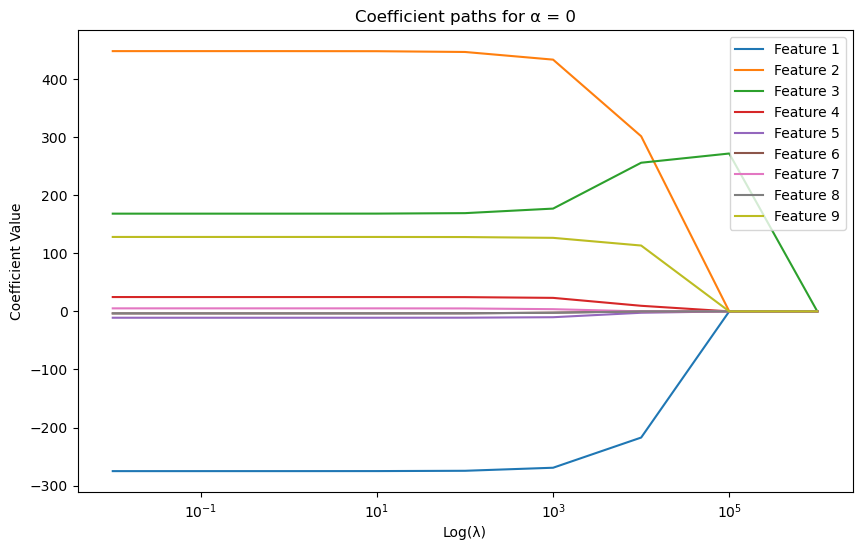

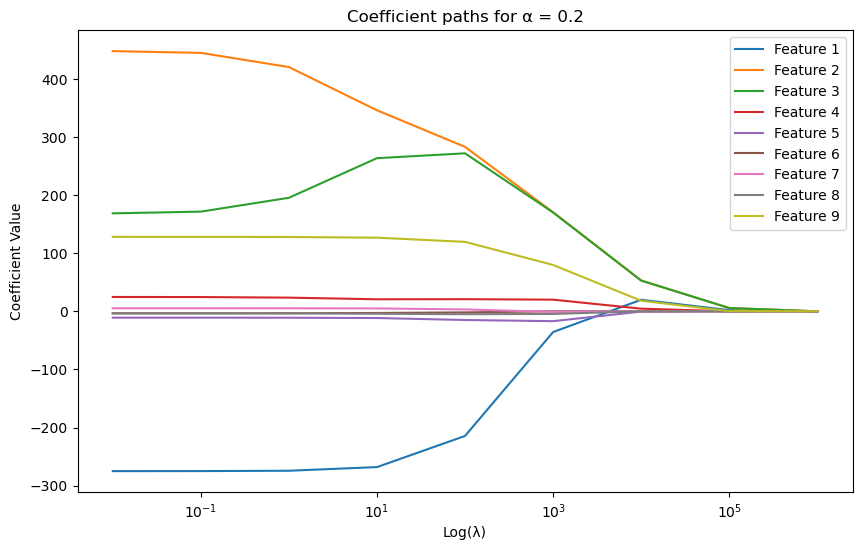

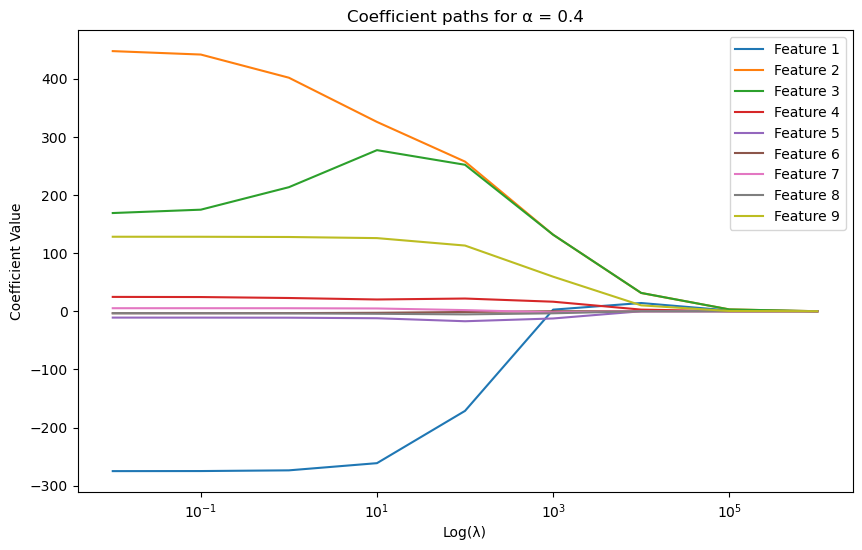

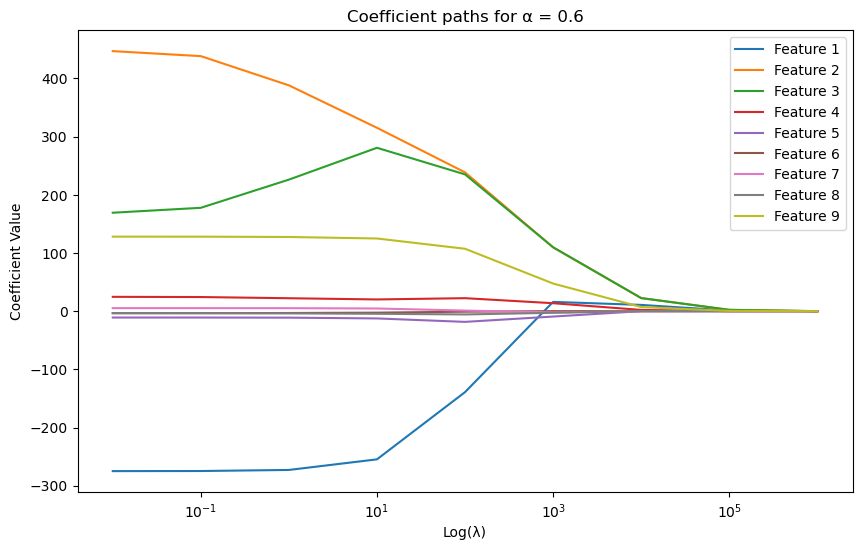

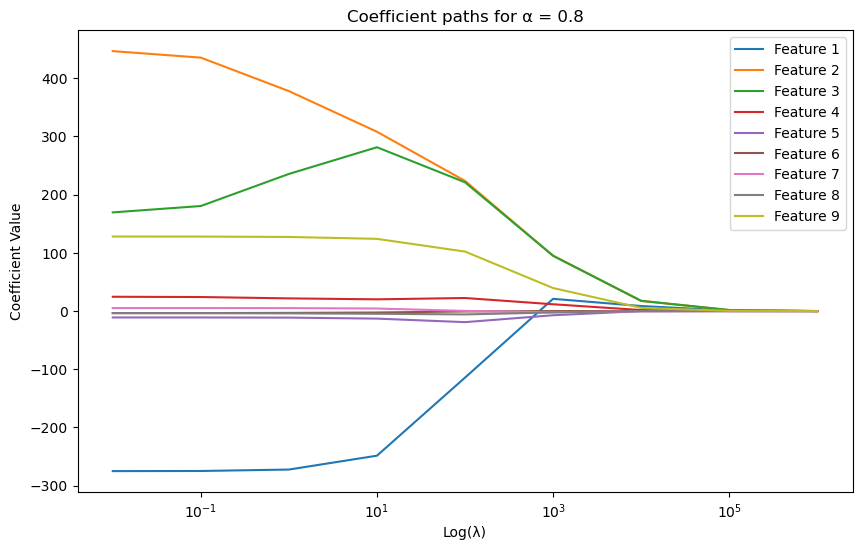

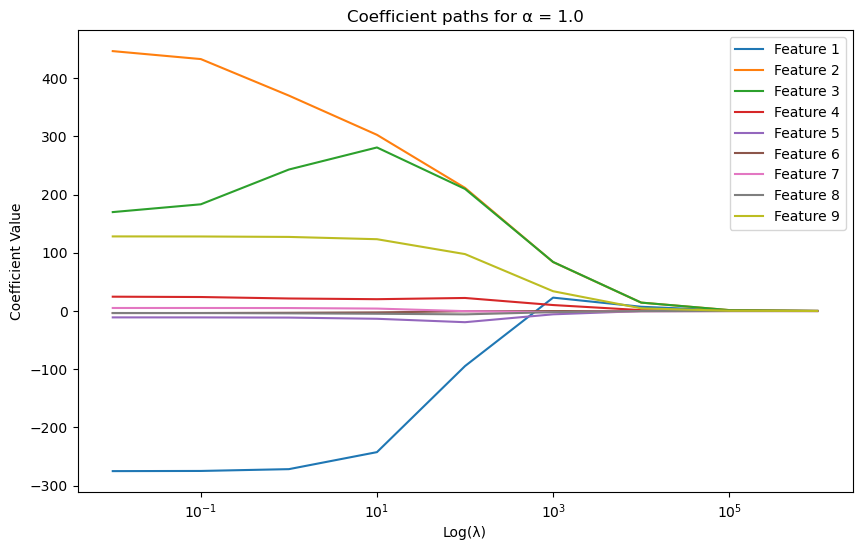

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess data
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

# Separate target and features
x_features_df = advertising_df.copy(deep=True)
y_features_df = x_features_df.pop("Balance")

# Convert categorical variables to dummy variables
x_features_df = pd.get_dummies(x_features_df, columns=["Gender", "Married", "Student"], drop_first=True, dtype=int)

# Standardize features and target
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()
y_standardized = y_features_df - y_features_df.mean()

# Convert to numpy arrays for efficiency
X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

learning_rate_alpha = 10 ** -5
# Define algorithm parameters
alpha_set = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
lambda_set = [10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
k_folds = 5
max_iters = 1000


def cross_validate_elastic_net(X, y, alpha_set, lambda_set, k_folds=5, max_iters=1000):
    fold_size = len(y) // k_folds
    errors = np.zeros((len(alpha_set), len(lambda_set)))

    for alpha_idx, alpha in enumerate(alpha_set):
        for lambda_idx, lambd in enumerate(lambda_set):
            fold_errors = []
            for fold in range(k_folds):
                # Split data for validation and training
                start, end = fold * fold_size, (fold + 1) * fold_size
                X_val, y_val = X[start:end], y[start:end]
                X_train = np.concatenate([X[:start], X[end:]])
                y_train = np.concatenate([y[:start], y[end:]])

                # Precompute b_k for training set
                b_k = np.sum(X_train ** 2, axis=0)
                
                # Initialize beta for coordinate descent
                beta = np.random.uniform(-1, 1, X_train.shape[1])
                
                # Perform coordinate descent for the elastic net
                for _ in range(max_iters):
                    for k in range(len(beta)):
                        # Calculate r_k using the current beta
                        r_k = y_train - X_train.dot(beta) + X_train[:, k] * beta[k]
                        a_k = X_train[:, k].dot(r_k)
                        
                        # Update beta[k] using the elastic net formula
                        if a_k > lambd * (1 - alpha) / 2:
                            beta[k] = (a_k - lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                        elif a_k < -lambd * (1 - alpha) / 2:
                            beta[k] = (a_k + lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                        else:
                            beta[k] = 0

                # Validation error
                y_pred_val = X_val @ beta
                mse = np.mean((y_val - y_pred_val) ** 2)
                fold_errors.append(mse)

            errors[alpha_idx, lambda_idx] = np.mean(fold_errors)
    
    return errors


# Calculate cross-validation errors for each combination of alpha and lambda
errors = cross_validate_elastic_net(X, y, alpha_set, lambda_set)

# Find the minimum error and corresponding alpha, lambda
min_error_idx = np.unravel_index(np.argmin(errors, axis=None), errors.shape)
optimal_alpha = alpha_set[min_error_idx[0]]
optimal_lambda = lambda_set[min_error_idx[1]]
print(f"Optimal alpha: {optimal_alpha}, Optimal lambda: {optimal_lambda}")

# Retrain on full dataset using optimal parameters
b_k = np.sum(X ** 2, axis=0)
optimal_beta = np.random.uniform(-1, 1, X.shape[1])

# Coordinate Descent for Optimal Alpha and Lambda
for _ in range(max_iters):
    for k in range(len(optimal_beta)):
        r_k = y - X.dot(optimal_beta) + X[:, k] * optimal_beta[k]
        a_k = X[:, k].dot(r_k)

        if a_k > optimal_lambda * (1 - optimal_alpha) / 2:
            optimal_beta[k] = (a_k - optimal_lambda * (1 - optimal_alpha) / 2) / (b_k[k] + optimal_lambda * optimal_alpha)
        elif a_k < -optimal_lambda * (1 - optimal_alpha) / 2:
            optimal_beta[k] = (a_k + optimal_lambda * (1 - optimal_alpha) / 2) / (b_k[k] + optimal_lambda * optimal_alpha)
        else:
            optimal_beta[k] = 0

print("Optimal Elastic Net Coefficients:", optimal_beta)

# Retrain for ridge (alpha=1) and lasso (alpha=0) for comparison
ridge_beta = np.random.uniform(-1, 1, X.shape[1])
lasso_beta = np.random.uniform(-1, 1, X.shape[1])

for alpha, beta in zip([1, 0], [ridge_beta, lasso_beta]):
    for _ in range(max_iters):
        for k in range(len(beta)):
            r_k = y - X.dot(beta) + X[:, k] * beta[k]
            a_k = X[:, k].dot(r_k)

            if a_k > optimal_lambda * (1 - alpha) / 2:
                beta[k] = (a_k - optimal_lambda * (1 - alpha) / 2) / (b_k[k] + optimal_lambda * alpha)
            elif a_k < -optimal_lambda * (1 - alpha) / 2:
                beta[k] = (a_k + optimal_lambda * (1 - alpha) / 2) / (b_k[k] + optimal_lambda * alpha)
            else:
                beta[k] = 0

print("Ridge Coefficients:", ridge_beta)
print("Lasso Coefficients:", lasso_beta)

# Plot function for Task 1: Coefficient paths
def plot_coefficients_vs_lambda(coefficients, alpha, lambda_set):
    plt.figure(figsize=(10, 6))
    for i, coeff in enumerate(coefficients.T):
        plt.semilogx(lambda_set, coeff, label=f"Feature {i+1}")
    plt.xlabel('Log(λ)')
    plt.ylabel('Coefficient Value')
    plt.title(f"Coefficient paths for α = {alpha}")
    plt.legend(loc='best')
    plt.show()

# Plot Task 1: Coefficients for each alpha
for alpha in alpha_set:
    coeffs = []
    for lambd in lambda_set:
        beta = np.random.uniform(-1, 1, X.shape[1])
        for _ in range(max_iters):
            for k in range(len(beta)):
                r_k = y - X.dot(beta) + X[:, k] * beta[k]
                a_k = X[:, k].dot(r_k)

                if a_k > lambd * (1 - alpha) / 2:
                    beta[k] = (a_k - lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                elif a_k < -lambd * (1 - alpha) / 2:
                    beta[k] = (a_k + lambd * (1 - alpha) / 2) / (b_k[k] + lambd * alpha)
                else:
                    beta[k] = 0
        coeffs.append(beta)
    plot_coefficients_vs_lambda(np.array(coeffs), alpha, lambda_set)
